         Vant hoff calculator.         


Enter your enthalpy value in KJ/mol:  -57
Enter equillibrium constant K1 at 298.15 K 0.15


Enthalpy: -57.0 KJ/mol
K eq at 298.15: 0.15
------------------------------------------------------------
 Temperature (K) | K_eq Value | Delta G° (kJ/mol) 
----------------------------------------------------------------------
 300 K |   1.3017e-01 |      5.09 kJ/mol
 350 K |   4.9735e-03 |     15.43 kJ/mol
 400 K |   4.2981e-04 |     25.78 kJ/mol


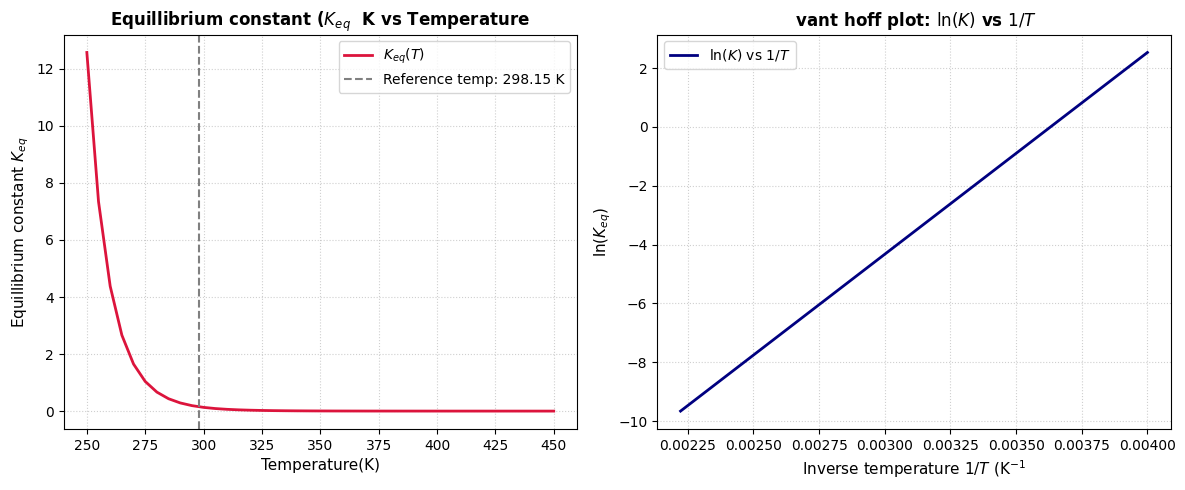

In [1]:
%matplotlib inline
import math
import matplotlib.pyplot as plt

#stage 1: custom inputs
print('='*60)
print('         Vant hoff calculator.         ')
print('='*60)

try:
	 delta_H_input = input('Enter your enthalpy value in KJ/mol: ')
	 if not delta_H_input:
	 	delta_H = -57.1
	 else:
	 	delta_H = float(delta_H_input)
except (EOFError, ValueError):
	delta_H = -57.1
	
try:
	K1_input = input('Enter equillibrium constant K1 at 298.15 K')
	if not K1_input:
		K1 = 0.15
	else:
		K1 = float(K1_input)
except(EOFError, ValueError):
	K1 = 0.15
	
T1 = 298.15 
R = 8.314/1000 

print(f'Enthalpy: {delta_H} KJ/mol')
print(f'K eq at {T1}: {K1}')

print('-'*60)

#stage 2: create temp lists
temperatures = list(range(250, 455, 5))
ln_K_values = []
K_values = []
delta_G_values = []
inv_temperatures = []

#stage 3: calculate
ln_K1 = math.log(K1)
for T in temperatures:
    ln_K2 = ln_K1 + (delta_H/R) * ((1.0/T1 - 1.0/T))
    K2 = math.exp(ln_K2)
    dG = -R * T * ln_K2

    ln_K_values.append(ln_K2)
    K_values.append(K2)
    delta_G_values.append(dG)
    inv_temperatures.append(1.0/T)

#stage 4: display printed table
test_temps = [300, 350, 400] 
print( ' Temperature (K) | K_eq Value | Delta G°' ' (kJ/mol) ' ) 
print('-' * 70) 
for T_test in test_temps: 
    ln_K_test = ln_K1 + (delta_H / R) * ((1.0 / T1) - (1.0 / T_test)) 
    K_test = math.exp(ln_K_test) 
    dG_test = -R * T_test * ln_K_test 
    print( f' {T_test} K | {K_test:12.4e} | ' f' {dG_test:8.2f} kJ/mol' ) 

print('=' * 60)

#stage 5: plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

#subplot1 keq vs temp
ax1.plot(
     temperatures, K_values, color='crimson', linewidth=2, label=r'$K_{eq}(T)$'
)
ax1.axvline(T1, color='gray', linestyle='--', label=f'Reference temp: {T1} K')
ax1.set_title(
        r'Equillibrium constant ($K_{eq}$  K vs Temperature', 
        fontsize=12, 
        fontweight='bold',
 )
ax1.set_xlabel('Temperature(K)', fontsize=11)
ax1.set_ylabel(r'Equillibrium constant $K_{eq}$', fontsize=11) 
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=10)
 
 #subplot 2 vant hoff plot (lnK vs 1/T)
ax2.plot(
         inv_temperatures,
         ln_K_values,
         color='navy',
         linewidth=2,
         label=r'$\ln(K)$ vs $1/T$',
)
ax2.set_title(r' vant hoff plot: $\ln(K)$ vs $1/T$', fontsize=12, fontweight='bold')
ax2.set_xlabel(r'Inverse temperature $1/T$ (K$^{-1}$', fontsize=11)
ax2.set_ylabel(r'$\ln(K_{eq})$', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()